# Graph Observation Spaces — IEEE 14-Bus Grid

Loads an observation from `l2rpn_case14_sandbox` **after a topology action that
splits substation 1** (generator 0 and line-origin 2 moved to bus 2).

All four converters are shown side-by-side. The two converters that encode
connectivity via edge metadata use `EdgeStyle` to colour edges:

| Converter | Colouring |
|---|---|
| `HeterogeneousGraphObservationConverter` | orange `--` = powerline · green = same-bus · crimson `:` = diff-bus |
| `ElementGraphObservationConverter` | green = active connection · gray = inactive |


In [2]:
import sys
from pathlib import Path

import grid2op
import matplotlib.pyplot as plt
from lightsim2grid import LightSimBackend

project_root = Path.cwd().parent.parent
src_root = project_root / "src"
for p in (str(project_root), str(src_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

from grid2op_env.observation_converter import (
    ElementGraphObservationConverter,
    GraphObservationConverter,
    HeterogeneousGraphObservationConverter,
    LODFGraphObservationConverter,
    PTDFGraphObservationConverter,
    SubstationGraphObservationConverter,
    ZbusGraphObservationConverter,
    EDGE_INDEX, EDGE_MASK, EDGES,
)
from visualization.utils import PlottingArgs, get_node_styles, get_edge_styles, visualize_graph

plt.style.use("default")

In [3]:
env = grid2op.make("l2rpn_case14_sandbox")
env.reset()

action = env.action_space({
    "set_bus": {
        "generators_id": [(0, 2)],
        "lines_or_id":   [(2, 2)],
    }
})
obs, _, done, _ = env.step(action)
if done:
    print("Topology action caused game-over — using initial observation.")
    obs = env.reset()
else:
    print(f"Elements on bus 2: {(obs.topo_vect == 2).sum()}")

Elements on bus 2: 2


/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/Backend/pandaPowerBackend.py:957: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self._grid.line["in_service"].iat[id_powerline_backend] = True
/home/adrian/.conda/envs/L2RPN

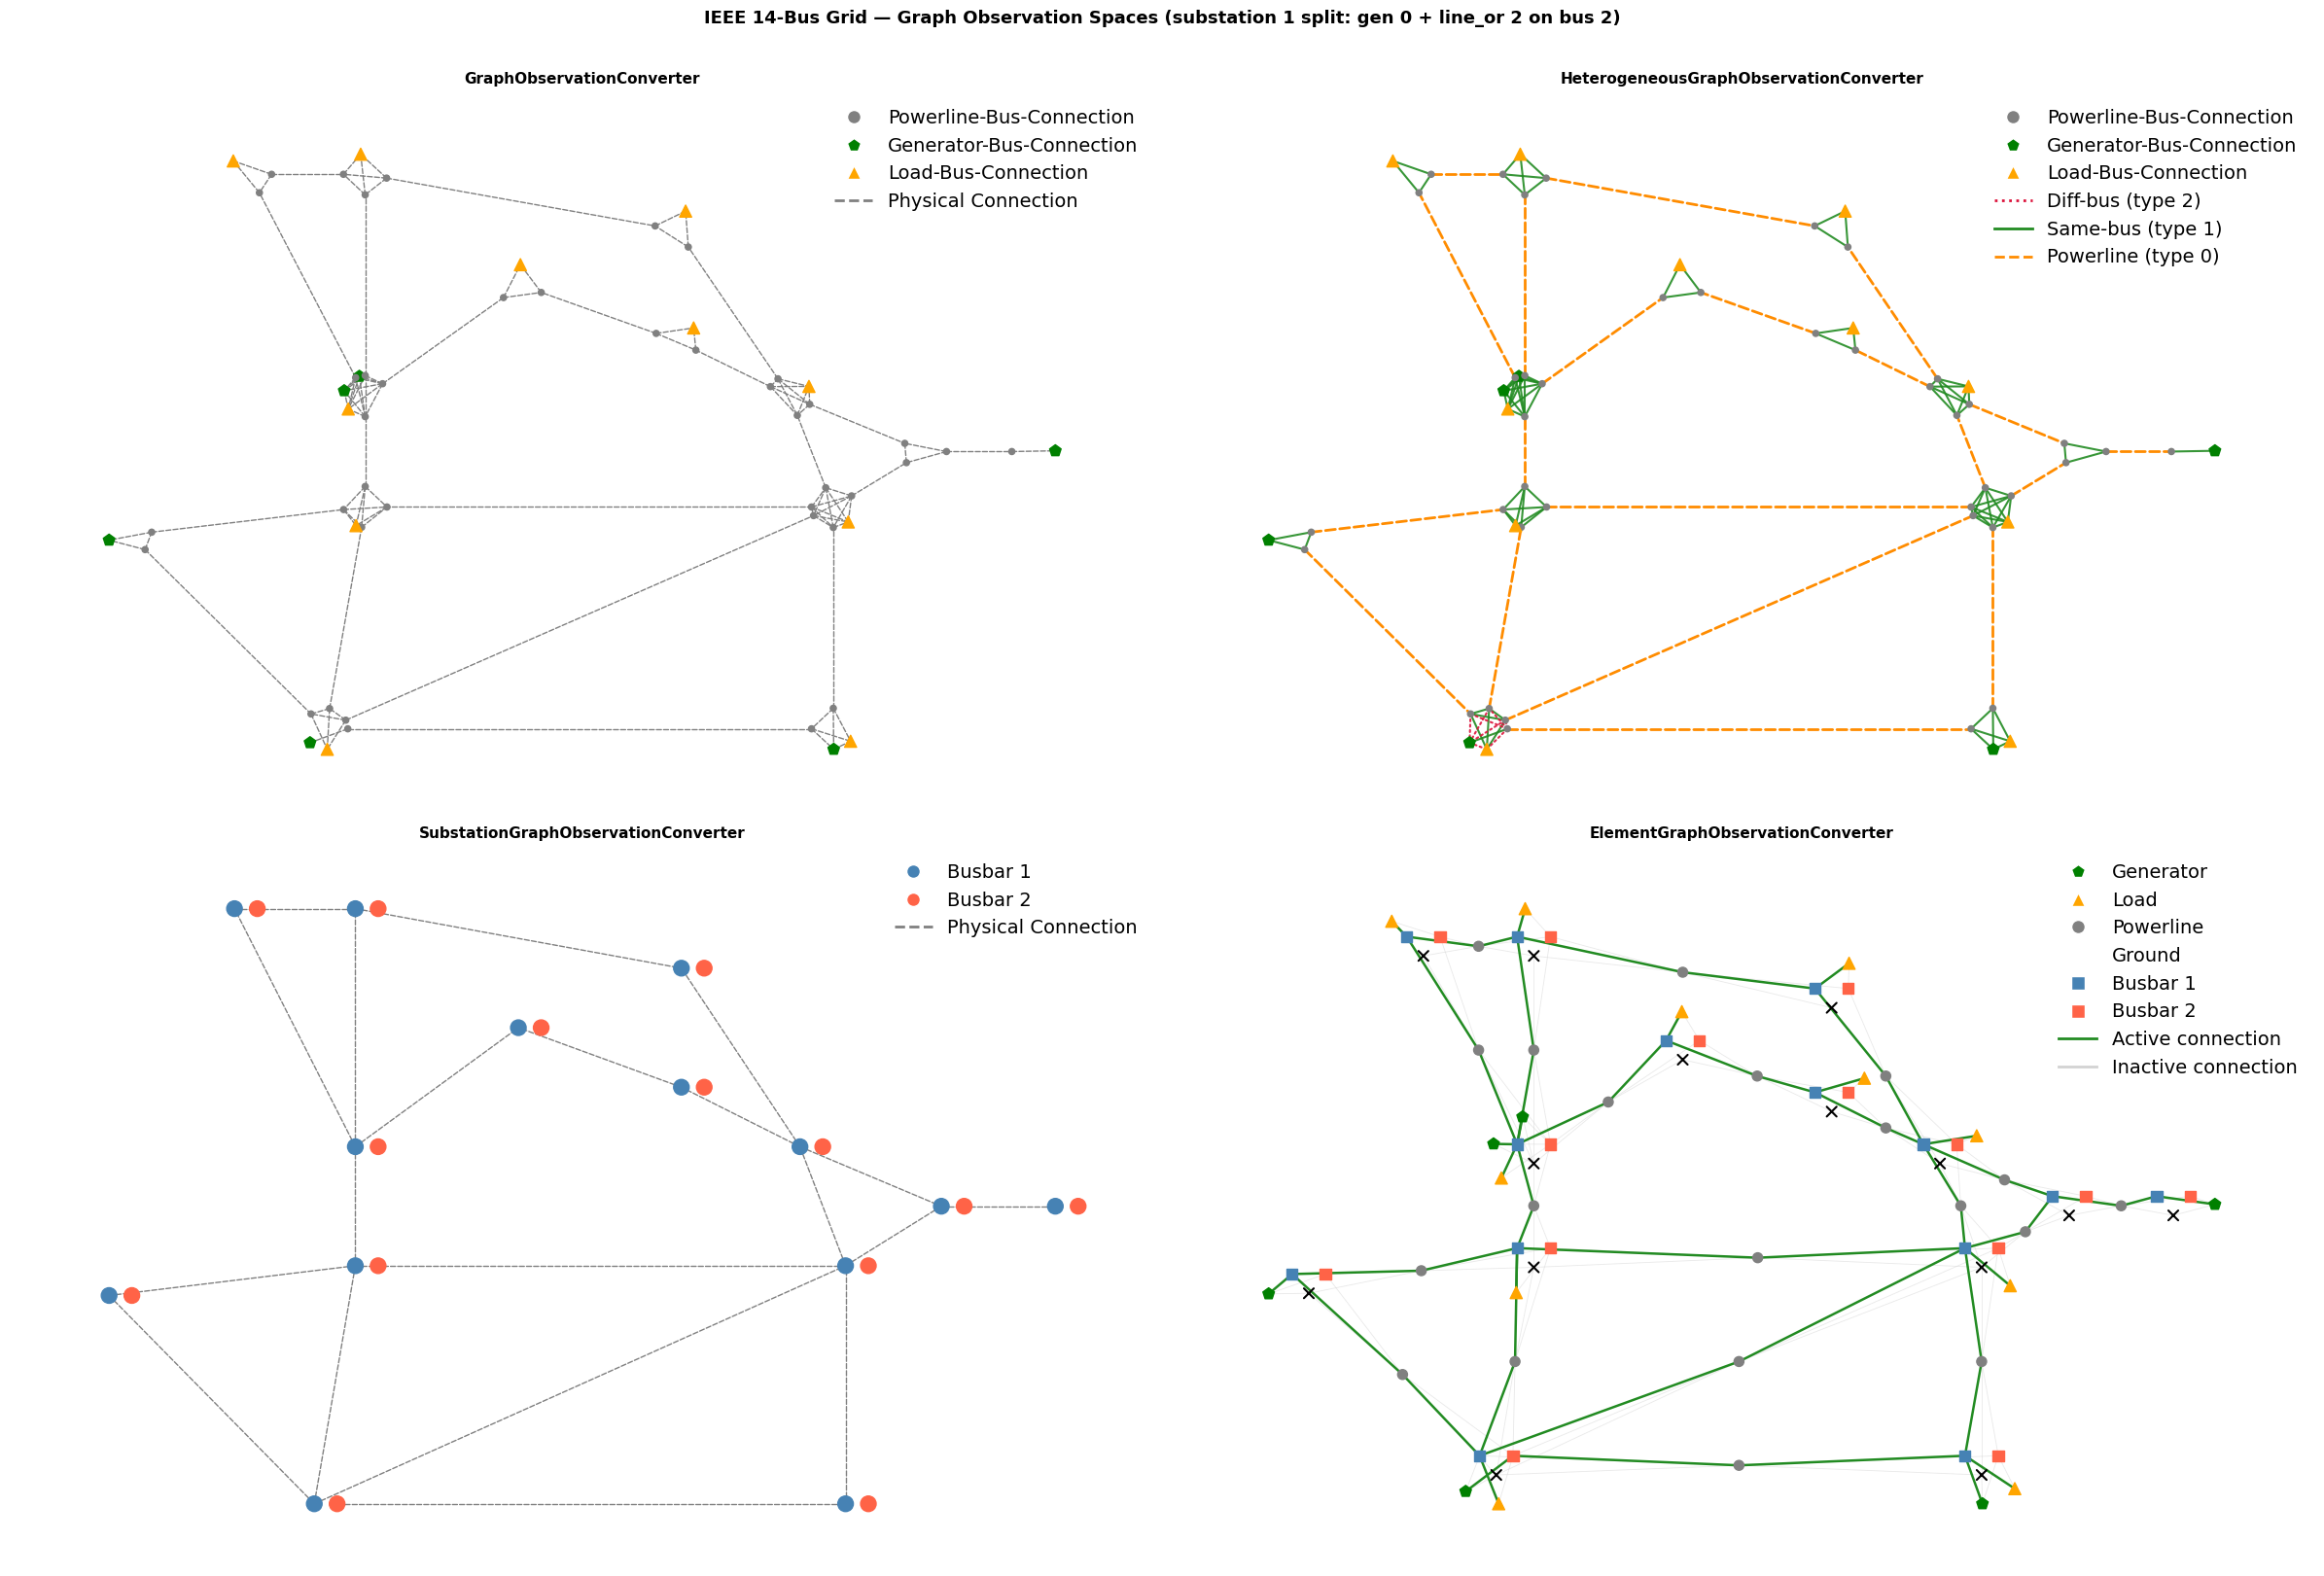

In [4]:
converters = [
    ("GraphObservationConverter",              GraphObservationConverter(env.observation_space)),
    ("HeterogeneousGraphObservationConverter", HeterogeneousGraphObservationConverter(env.observation_space)),
    ("SubstationGraphObservationConverter",    SubstationGraphObservationConverter(env.observation_space)),
    ("ElementGraphObservationConverter",       ElementGraphObservationConverter(env.observation_space)),
]

fig, axs = plt.subplots(2, 2, figsize=(24, 16), dpi=100)

for ax, (title, converter) in zip(axs.flat, converters):
    gym_obs     = converter.to_gym(obs)
    edge_mask   = gym_obs[EDGE_MASK].astype(bool)
    edge_index  = gym_obs[EDGE_INDEX][:, edge_mask]
    node_styles = get_node_styles(env, type(converter))
    edge_styles = get_edge_styles(gym_obs, type(converter))

    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=edge_index,
        node_styles=node_styles,
        edge_styles=edge_styles,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.suptitle(
    "IEEE 14-Bus Grid — Graph Observation Spaces (substation 1 split: gen 0 + line_or 2 on bus 2)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

## Topology- and Impedance-based Graph Representations

The three converters below require a **LightSimBackend** environment (PTDF, LODF, and Ybus are computed directly from the C++ grid model).

Edges are **fully connected** — every pair of buses (PTDF, Zbus) or every pair of lines (LODF) is connected.
Only the **top-K strongest edges** are shown to keep the plot readable; edge colour and width encode relative coupling strength (yellow → red = weak → strong).

| Converter | Nodes | Edge weight |
|---|---|---|
| `PTDFGraphObservationConverter` | Buses (2 × n_sub) | L1 PTDF distance (lower = more similar electrical response) |
| `LODFGraphObservationConverter` | Lines | \|LODF[i,j]\| (higher = stronger contingency coupling) |
| `ZbusGraphObservationConverter` | Buses (2 × n_sub) | 1 / \|Zbus[i,j]\| (higher = electrically closer) |

Elements on bus 2: 2


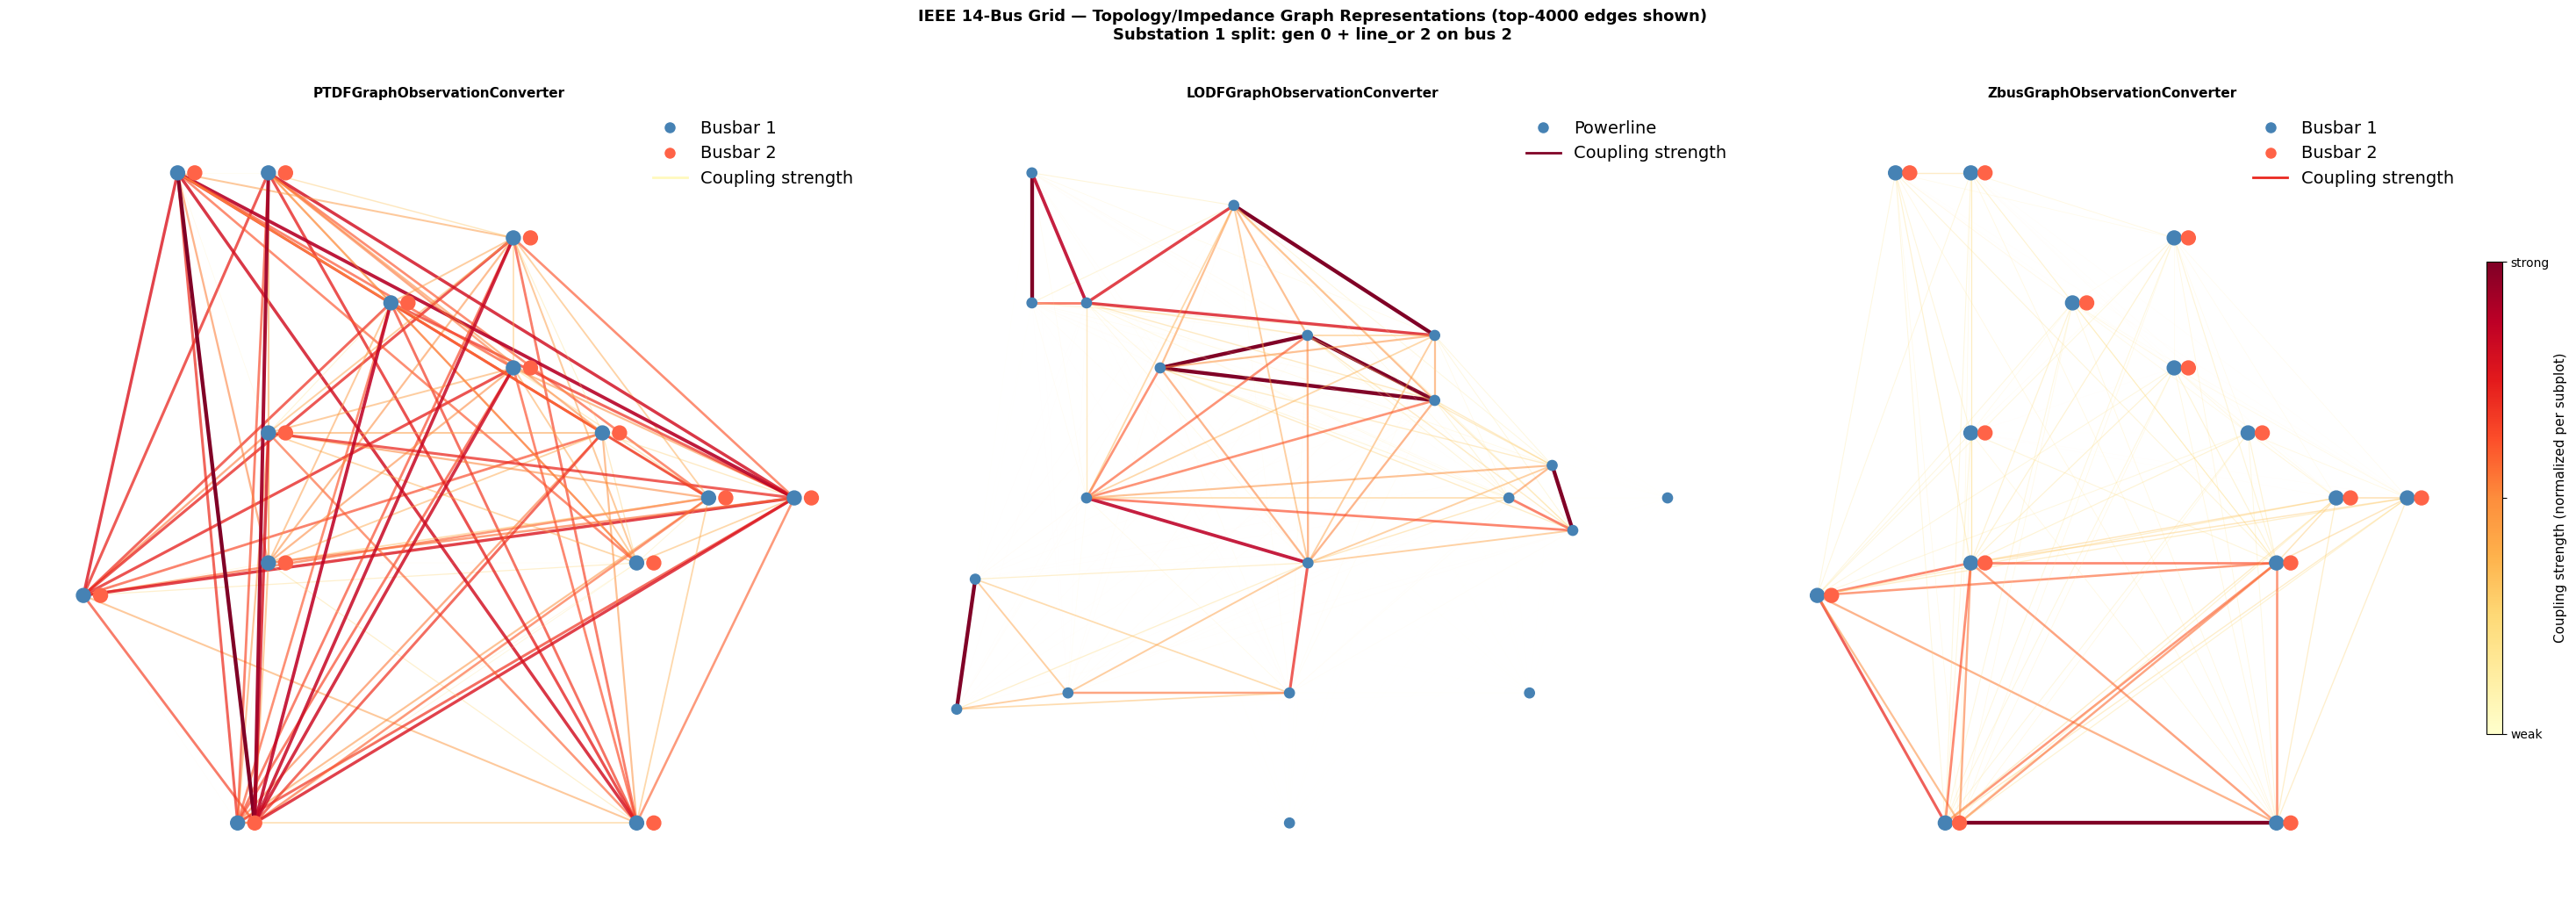

In [5]:
import numpy as np
import matplotlib.cm as mcm
import matplotlib.colors as mcolors_norm

# LightSimBackend environment — required for PTDF/LODF/Zbus computation.
env_ls = grid2op.make("l2rpn_case14_sandbox", backend=LightSimBackend())
env_ls.reset()

action_ls = env_ls.action_space({
    "set_bus": {
        "generators_id": [(0, 2)],
        "lines_or_id":   [(2, 2)],
    }
})
obs_ls, _, done_ls, _ = env_ls.step(action_ls)
if done_ls:
    print("Topology action caused game-over — using initial observation.")
    obs_ls = env_ls.reset()
else:
    print(f"Elements on bus 2: {(obs_ls.topo_vect == 2).sum()}")

TOP_K = 4000  # number of strongest edges to display per converter

converters_ls = [
    ("PTDFGraphObservationConverter",
     PTDFGraphObservationConverter(env_ls.backend, env_ls.observation_space)),
    ("LODFGraphObservationConverter",
     LODFGraphObservationConverter(env_ls.backend, env_ls.observation_space)),
    ("ZbusGraphObservationConverter",
     ZbusGraphObservationConverter(env_ls.backend, env_ls.observation_space)),
]

fig, axs = plt.subplots(1, 3, figsize=(30, 10), dpi=100)

for ax, (title, converter) in zip(axs, converters_ls):
    gym_obs = converter.to_gym(obs_ls)

    # Build a top-K mask: keep only the TOP_K edges with the highest |weight|
    # among those that are active (EDGE_MASK = True).
    active_mask = gym_obs[EDGE_MASK].astype(bool)
    weights_all = np.nan_to_num(np.abs(gym_obs[EDGES][:, 0]))
    active_idx  = np.where(active_mask)[0]
    top_idx     = active_idx[np.argsort(weights_all[active_idx])[-TOP_K:]]
    top_k_mask  = np.zeros(len(active_mask), dtype=bool)
    top_k_mask[top_idx] = True

    edge_index  = gym_obs[EDGE_INDEX][:, top_k_mask]
    node_styles = get_node_styles(env_ls, type(converter))
    edge_styles = get_edge_styles(gym_obs, type(converter), edge_mask=top_k_mask)

    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=edge_index,
        node_styles=node_styles,
        edge_styles=edge_styles,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=11, fontweight="bold")

# Shared colorbar — same YlOrRd cmap used by get_edge_styles, normalized 0→1 per subplot.
sm = mcm.ScalarMappable(cmap="YlOrRd", norm=mcolors_norm.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs[-1], shrink=0.6, aspect=30, pad=0.02)
cbar.set_label("Coupling strength (normalized per subplot)", fontsize=11)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(["weak", "", "strong"])

plt.suptitle(
    f"IEEE 14-Bus Grid — Topology/Impedance Graph Representations (top-{TOP_K} edges shown)\n"
    "Substation 1 split: gen 0 + line_or 2 on bus 2",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

## Combined Observation Spaces

Each of the three converters below layers a physics-driven edge type on top of a base graph topology:

| Converter | Base nodes | Type-0 edges | Type-1 edges |
|---|---|---|---|
| `ElementLODFGraphObservationConverter` | Elements (gen, load, line, storage, bus) | element → busbar (binary active) | LODF coupling: line[i] → line[j] |
| `SubstationPTDFGraphObservationConverter` | Busbars (2 × n_sub) | powerline topology | PTDF distance: all bus pairs |
| `SubstationZbusGraphObservationConverter` | Busbars (2 × n_sub) | powerline topology | Zbus admittance: all bus pairs |

Only the **top-K strongest physics edges** (type 1) are shown; type-0 topology edges are always shown in full.

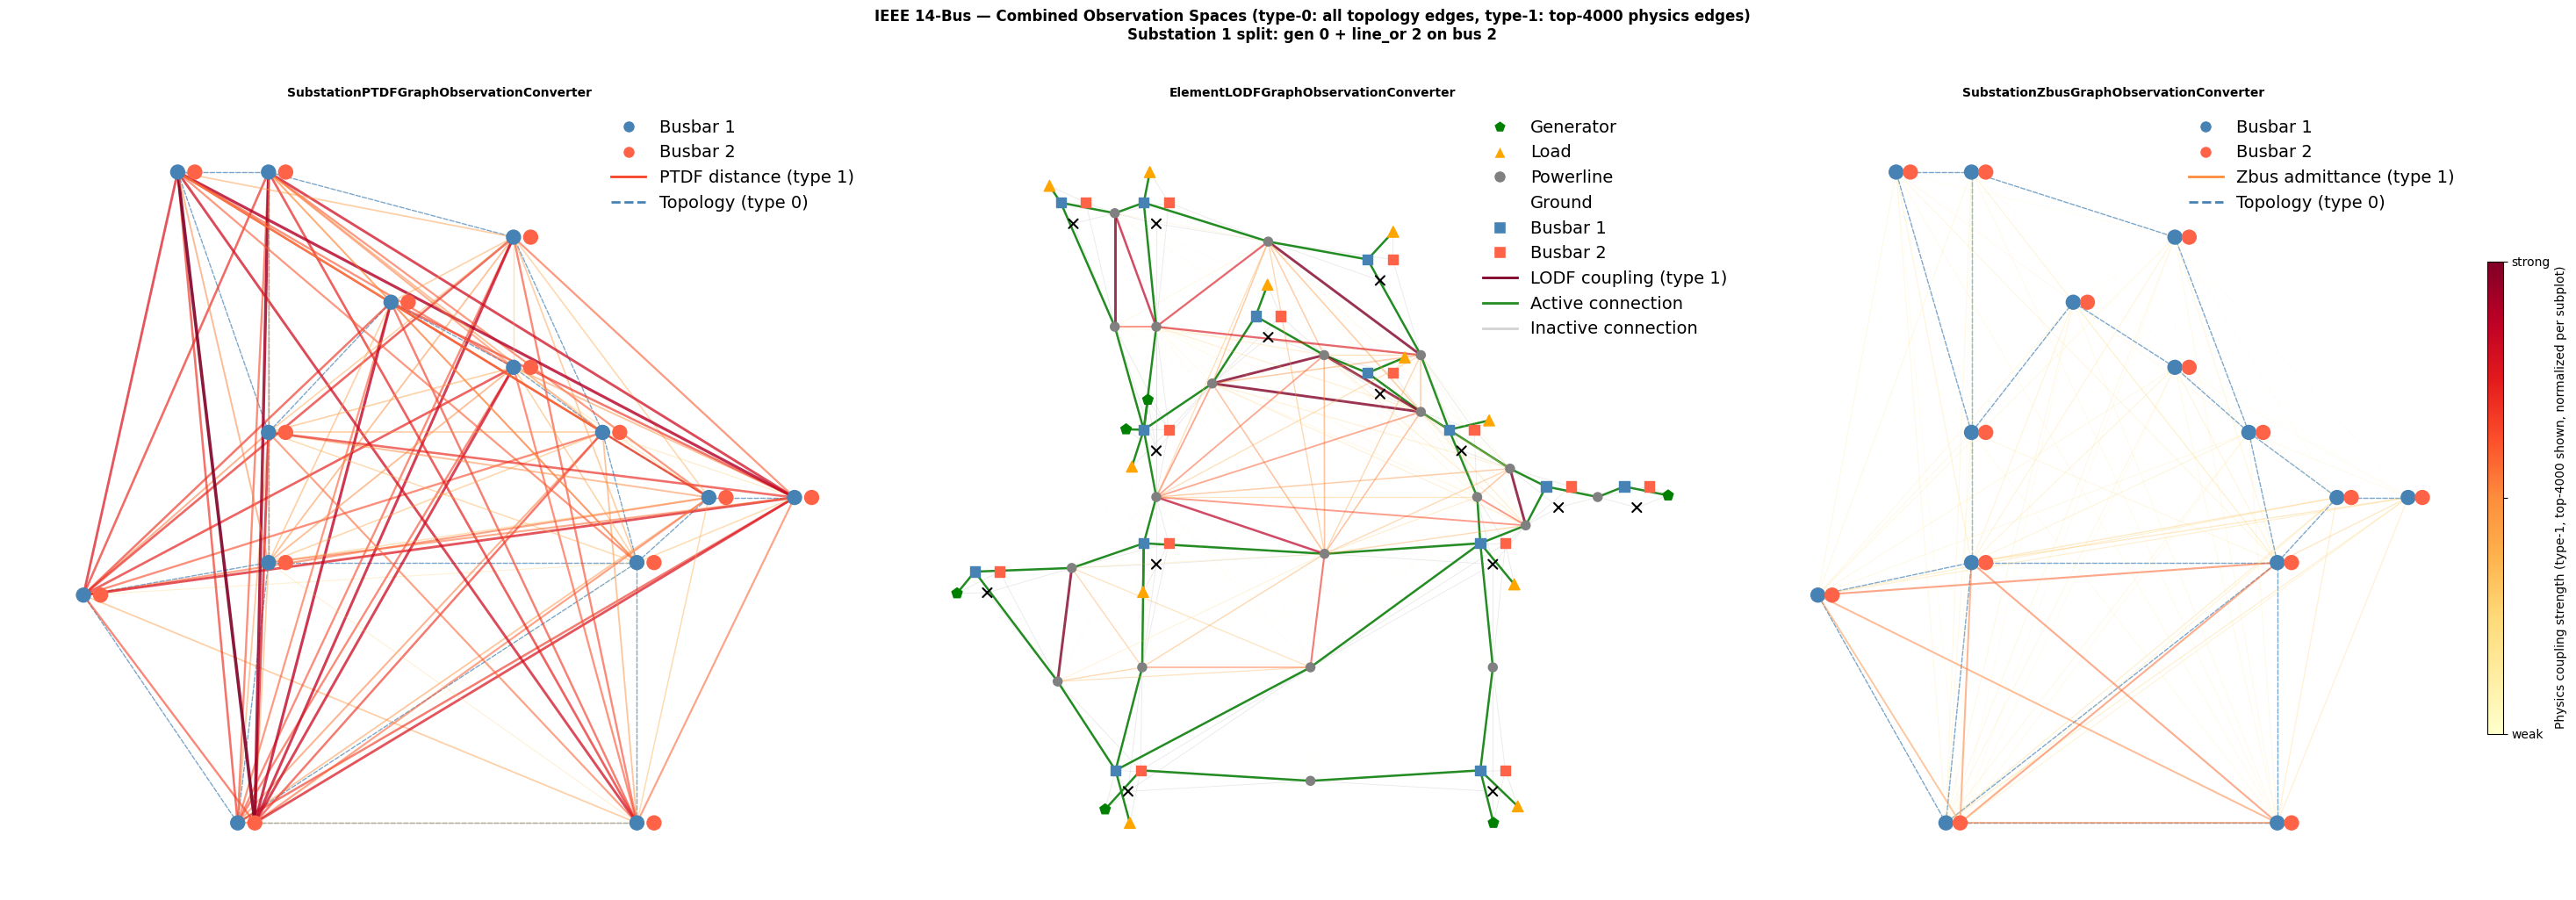

In [12]:
import numpy as np
from grid2op_env.observation_converter import (
    ElementLODFGraphObservationConverter,
    SubstationPTDFGraphObservationConverter,
    SubstationZbusGraphObservationConverter,
    EDGE_TYPE,
)

TOP_K = 4000  # strongest type-1 edges to display per converter

converters_combined = [
    ("SubstationPTDFGraphObservationConverter",
     SubstationPTDFGraphObservationConverter(
         backend=env_ls.backend, g2op_obs_space=env_ls.observation_space)),
    ("ElementLODFGraphObservationConverter",
     ElementLODFGraphObservationConverter(
         backend=env_ls.backend, g2op_obs_space=env_ls.observation_space)),
    ("SubstationZbusGraphObservationConverter",
     SubstationZbusGraphObservationConverter(
         backend=env_ls.backend, g2op_obs_space=env_ls.observation_space)),
]

fig, axs = plt.subplots(1, 3, figsize=(30, 10), dpi=100)

for ax, (title, converter) in zip(axs, converters_combined):
    gym_obs   = converter.to_gym(obs_ls)
    conv_type = type(converter)

    active_mask  = gym_obs[EDGE_MASK].astype(bool)
    edge_types   = gym_obs[EDGE_TYPE]
    edge_weights = np.nan_to_num(np.abs(gym_obs[EDGES][:, 0]))

    # Keep all type-0 (topology/element-bus) edges.
    topo_mask = active_mask & (edge_types == 0)

    # Keep top-K type-1 (physics) edges by weight.
    phys_idx   = np.where(active_mask & (edge_types == 1))[0]
    top_idx    = phys_idx[np.argsort(edge_weights[phys_idx])[-TOP_K:]]
    phys_mask  = np.zeros(len(active_mask), dtype=bool)
    phys_mask[top_idx] = True

    display_mask = topo_mask | phys_mask

    node_styles = get_node_styles(env_ls, conv_type)
    edge_styles = get_edge_styles(gym_obs, conv_type, edge_mask=display_mask)
    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=gym_obs[EDGE_INDEX][:, display_mask],
        node_styles=node_styles,
        edge_styles=edge_styles,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=10, fontweight="bold")

sm = mcm.ScalarMappable(cmap="YlOrRd", norm=mcolors_norm.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs[-1], shrink=0.6, aspect=30, pad=0.02)
cbar.set_label(f"Physics coupling strength (type-1, top-{TOP_K} shown, normalized per subplot)", fontsize=10)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(["weak", "", "strong"])

plt.suptitle(
    f"IEEE 14-Bus — Combined Observation Spaces (type-0: all topology edges, type-1: top-{TOP_K} physics edges)\n"
    "Substation 1 split: gen 0 + line_or 2 on bus 2",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()